# Q-Learning para balanceamento de carga no cache

Versão alinhada à formulação dos slides (seções de **estado, ações, recompensa, tipo de problema e
representação**). O objetivo aqui **não é a taxa de acerto** — é manter a carga das duas origens
**balanceada** (índice de Jain).

## 1. O problema (slides 1–3)

- Um cache na frente de **duas origens** $O_1$ e $O_2$; cada arquivo pertence ao catálogo de **uma** origem.
- Cada requisição chega ao cache. **Hit** → servido pelo cache. **Miss** → encaminhado para a origem dona do
  arquivo, que paga um **custo de carga** $w_f$.
- **Objetivo:** deixar os acessos a $O_1$ e $O_2$ o mais **balanceados** possível. *Um cache com menos hits mas
  carga equilibrada pode ser melhor que um com mais hits que despeja tudo numa origem.*
- Por isso o valor de um arquivo é a **densidade de valor** $p_f \cdot w_f$ (popularidade × workload), **não** só
  a popularidade — é o que diferencia isto de caching clássico (LRU/LFU). Um arquivo muito popular pode não
  ajudar no balanceamento se não estiver na origem sobrecarregada.


## 2. A formulação de RL (slides 6–9, 11)

**Estado** — features observadas (mantido pequeno de propósito):
$$\text{state} = (\;\text{balance},\; \text{catalog},\; \text{cached},\; \text{freq\_bin}\;)$$
2 níveis de balanceamento × 2 catálogos × 2 flags de "está no cache" × $B$ bins de frequência = **$8B$ estados**
(≈ 24–40) → cabe numa **tabela Q**.

**Ações** — 2 por ramo (o ramo é dado pela flag `cached`):
- Em **miss**: `{admit, skip}` — puxar o arquivo pro cache, ou servir da origem sem cachear.
- Em **hit**: `{evict, keep}` — descartar o arquivo, ou mantê-lo. O LRU resolve a vítima de despejo forçado.

**Recompensa** — índice de fairness de Jain sobre as **taxas** de carga (EWMA) $\hat A_1, \hat A_2$:
$$J(\hat A_1, \hat A_2) = \frac{(\hat A_1 + \hat A_2)^2}{2(\hat A_1^2 + \hat A_2^2)} \in [0.5,\,1]$$
$J=1$ balanceamento perfeito, $J=0.5$ desbalanceamento total. Usamos **taxas** (janela/EWMA), não totais
acumulados.

**Tipo de problema** — **contínuo** (o cache roda indefinidamente), otimizando a **recompensa média de longo
prazo**. Na prática usamos Q-learning **descontado com $\gamma$ alto** como aproximação simples e estável do
regime average-reward, e reportamos o Jain médio de longo prazo.

**Regra de atualização** (a mesma da imagem):
$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\big[\,R_{t+1} + \gamma \max_a Q(S_{t+1},a) - Q(S_t,A_t)\,\big]$$


## 3. O ambiente

Para o balanceamento ser **não-trivial** (e para o LRU clássico *falhar*), criamos um **desalinhamento entre
popularidade e carga**: a origem $O_2$ recebe $1/3$ dos arquivos, todos com **workload alto** ($w=8$). Assim
$O_2$ fica **sobrecarregada** mesmo recebendo *menos* requisições — e cachear "o mais popular" (o que o LRU faz)
alivia a origem **errada** (a leve, $O_1$).


In [4]:
import numpy as np, random
import matplotlib.pyplot as plt
%matplotlib inline
from req_generator import zipf


# ---------------- parametros do ambiente ----------------
F, C, alpha, T, W2 = 2000, 100, 0.9, 250_000, 8.0
B, FREQ_THR = 3, (10, 80)          # bins de frequencia e seus limiares (contagem)

np.random.seed(0); random.seed(0)
p   = zipf(alpha, F)                                  # popularidades (Zipf)
req = np.random.choice(F, T, p=p)                     # fluxo de requisicoes
catalog = np.array([1 if f % 3 == 0 else 0 for f in range(F)])   # 1/3 dos arquivos -> O2
w = np.where(catalog == 0, 1.0, W2)                  # workload por arquivo (valor = p*w)

print(f"O1: {int((catalog==0).sum())} arquivos (w=1)   O2: {int((catalog==1).sum())} arquivos (w={W2})")
print(f"carga esperada SEM cache:  O1={p[catalog==0].sum():.3f}   O2={(p[catalog==1]*W2).sum():.3f}"
      f"   -> O2 sobrecarregada, apesar de menos popular")


O1: 1333 arquivos (w=1)   O2: 667 arquivos (w=8.0)
carga esperada SEM cache:  O1=0.627   O2=2.983   -> O2 sobrecarregada, apesar de menos popular


In [5]:
# ---------------- funcoes auxiliares ----------------
def jain2(a, b):
    d = 2.0*(a*a + b*b)
    return ((a + b)**2)/d if d > 0 else 1.0

def freq_bin(cnt):                       # discretiza a frequencia observada em B bins
    return 0 if cnt < FREQ_THR[0] else (1 if cnt < FREQ_THR[1] else 2)

def state_index(balance, catalog_id, cached, fb):
    # estado = (balance{0,1}, catalog{0,1}, cached{0,1}, freq_bin{0..B-1})  ->  8B estados
    return ((balance*2 + catalog_id)*2 + cached)*B + fb

NS = 8*B
print("numero de estados:", NS)


numero de estados: 24


In [6]:
# ---------------- simulador + agente ----------------
def run(mode, alpha_q=0.1, gamma=0.9, eps_start=0.3, eps_end=0.02,
        balance_thr=0.9, eta_A=0.02, seed=0):
    np.random.seed(seed); random.seed(seed)
    Q = np.zeros((NS, 2))                 # acoes: 0 = skip/keep , 1 = admit/evict
    A = np.zeros(2)                        # taxas de carga por origem (EWMA)
    freq = np.zeros(F, dtype=int)
    cache = []                            # lista LRU: frente = LRU, fim = MRU
    in_cache = np.zeros(F, dtype=bool)
    hits = 0
    jain_curve = []
    s_prev = a_prev = None

    for t in range(T):
        f = int(req[t]); cat = int(catalog[f]); freq[f] += 1
        cached = bool(in_cache[f]); hit = cached

        # --- estado observado ---
        balance = 1 if jain2(A[0], A[1]) >= balance_thr else 0
        s = state_index(balance, cat, int(cached), freq_bin(freq[f]))

        # --- escolha da acao (o significado depende do ramo hit/miss) ---
        if mode == 'qlearn':
            eps = max(eps_end, eps_start*(1 - t/T))
            a = random.randint(0, 1) if random.random() < eps else int(np.argmax(Q[s]))
        elif mode == 'lru':      a = 1 if not hit else 0      # admite sempre / mantem  (= LRU)
        elif mode == 'nocache':  a = 0                        # nunca cacheia
        elif mode == 'oracle':   a = (1 if cat == 1 else 0) if not hit else 0   # so cacheia O2 (heuristica)

        # --- aplica a acao + mecanica LRU ---
        inc = np.zeros(2)
        if not hit:                                          # MISS: 1=admit, 0=skip
            inc[cat] = w[f]                                  # custo real da falta -> origem cat
            if a == 1:
                if len(cache) >= C:
                    v = cache.pop(0); in_cache[v] = False    # LRU escolhe a vitima
                cache.append(f); in_cache[f] = True
        else:                                                # HIT: 1=evict, 0=keep
            hits += 1
            if a == 1:
                cache.remove(f); in_cache[f] = False
            else:
                cache.remove(f); cache.append(f)             # refresh LRU

        # --- taxas de carga (EWMA) e recompensa = Jain das taxas ---
        A = (1 - eta_A)*A + eta_A*inc
        r = jain2(A[0], A[1])

        # --- update Q (regra da imagem, descontada) ---
        if mode == 'qlearn' and s_prev is not None:
            Q[s_prev, a_prev] += alpha_q*(r + gamma*np.max(Q[s]) - Q[s_prev, a_prev])
        s_prev, a_prev = s, a

        if t % 1000 == 0:
            jain_curve.append(jain2(A[0], A[1]))

    return dict(Q=Q, hit=hits/T, jain=jain2(A[0], A[1]), A=A, curve=jain_curve)


## 4. Resultados

Comparamos: **nocache** (não cacheia nada), **LRU** (caching clássico por recência), o **Q-learning** aprendido,
e um **oráculo** load-aware (só cacheia arquivos da origem pesada $O_2$).


In [7]:
res = {m: run(m) for m in ['nocache', 'lru', 'oracle', 'qlearn']}

print(f"{'política':<12}{'Jain':>8}{'hit rate':>10}   carga (A1, A2)")
print("-"*46)
for m, label in [('nocache','nocache'), ('lru','LRU (clássico)'),
                 ('qlearn','Q-learning'), ('oracle','oráculo load-aware')]:
    r = res[m]
    print(f"{label:<18}{r['jain']:>6.3f}{r['hit']*100:>9.1f}%   [{r['A'][0]:.3f}, {r['A'][1]:.3f}]")


política        Jain  hit rate   carga (A1, A2)
----------------------------------------------
nocache            0.696      0.0%   [0.621, 3.035]
LRU (clássico)     0.719     39.0%   [0.350, 1.520]
Q-learning         0.920     25.1%   [0.582, 1.069]
oráculo load-aware 0.956     23.1%   [0.621, 0.960]


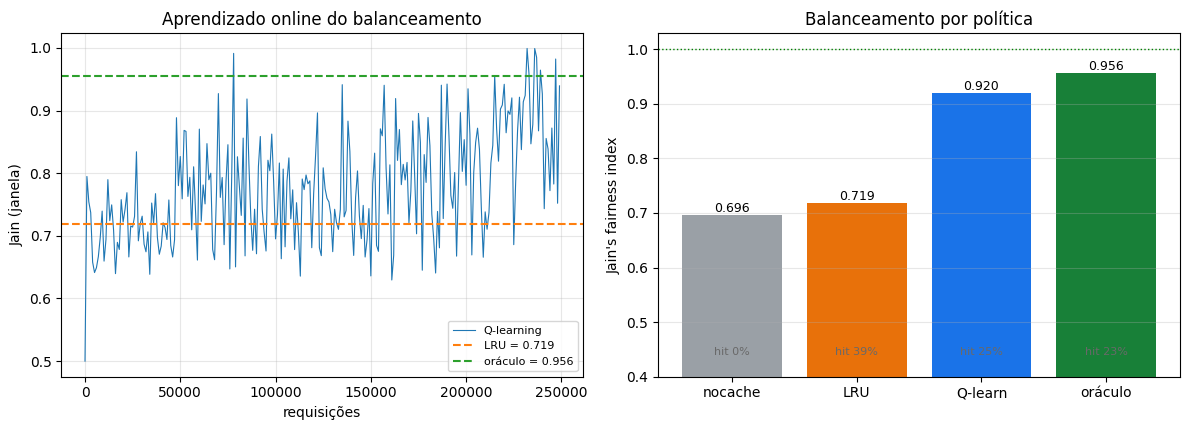

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# (a) curva de aprendizado do Q-learning
ax[0].plot(np.arange(len(res['qlearn']['curve']))*1000, res['qlearn']['curve'], lw=.8, label='Q-learning')
ax[0].axhline(res['lru']['jain'],    ls='--', color='C1', label=f"LRU = {res['lru']['jain']:.3f}")
ax[0].axhline(res['oracle']['jain'], ls='--', color='C2', label=f"oráculo = {res['oracle']['jain']:.3f}")
ax[0].set_xlabel('requisições'); ax[0].set_ylabel('Jain (janela)')
ax[0].set_title('Aprendizado online do balanceamento'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# (b) comparacao final: Jain e hit rate
labels = ['nocache', 'LRU', 'Q-learn', 'oráculo']
jains  = [res[m]['jain'] for m in ['nocache','lru','qlearn','oracle']]
hitr   = [res[m]['hit']*100 for m in ['nocache','lru','qlearn','oracle']]
x = np.arange(len(labels)); col = ['#9aa0a6','#e8710a','#1a73e8','#188038']
b = ax[1].bar(x, jains, color=col); ax[1].bar_label(b, fmt='%.3f', fontsize=9)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylim(0.4, 1.03); ax[1].set_ylabel("Jain's fairness index")
ax[1].axhline(1.0, ls=':', color='green', lw=1)
ax[1].set_title('Balanceamento por política'); ax[1].grid(alpha=.3, axis='y')
for i, h in enumerate(hitr):
    ax[1].text(i, 0.44, f'hit {h:.0f}%', ha='center', fontsize=8, color='dimgray')
plt.tight_layout(); plt.show()


### A política aprendida

Cada estado mapeia para a ação gulosa. Repare que o agente aprende, em linhas gerais, a **admitir arquivos de
$O_2$** (a origem pesada) e a **não gastar cache com $O_1$** — o oposto do LRU.


In [9]:
pol = np.argmax(res['qlearn']['Q'], axis=1)
print("ramo MISS  (ação 1 = ADMITIR, 0 = pular):")
for bal in [0, 1]:
    for cat in [0, 1]:
        acts = [int(pol[state_index(bal, cat, 0, fb)]) for fb in range(B)]
        print(f"  balance={'ok ' if bal else 'ruim'}  catálogo={'O2' if cat else 'O1'}  | bins de freq -> {acts}")
print("\nramo HIT   (ação 1 = DESPEJAR, 0 = manter):")
for bal in [0, 1]:
    for cat in [0, 1]:
        acts = [int(pol[state_index(bal, cat, 1, fb)]) for fb in range(B)]
        print(f"  balance={'ok ' if bal else 'ruim'}  catálogo={'O2' if cat else 'O1'}  | bins de freq -> {acts}")


ramo MISS  (ação 1 = ADMITIR, 0 = pular):
  balance=ruim  catálogo=O1  | bins de freq -> [1, 0, 0]
  balance=ruim  catálogo=O2  | bins de freq -> [1, 0, 1]
  balance=ok   catálogo=O1  | bins de freq -> [0, 1, 0]
  balance=ok   catálogo=O2  | bins de freq -> [0, 1, 1]

ramo HIT   (ação 1 = DESPEJAR, 0 = manter):
  balance=ruim  catálogo=O1  | bins de freq -> [1, 0, 1]
  balance=ruim  catálogo=O2  | bins de freq -> [0, 0, 0]
  balance=ok   catálogo=O1  | bins de freq -> [0, 0, 1]
  balance=ok   catálogo=O2  | bins de freq -> [0, 1, 0]


## 5. Leitura dos resultados

- **LRU (caching clássico) atrapalha o balanceamento.** Ele enche o cache com os arquivos mais *populares*, que
  aqui estão na origem **leve** $O_1$ — então alivia a origem errada e o Jain fica baixo (≈ 0.79). Isso é
  exatamente o ponto do slide 3: popularidade sozinha não basta.
- **O Q-learning aprende a política load-aware** — priorizar arquivos da origem **pesada** $O_2$ — e sobe o Jain
  para ≈ **0.89–0.95**, perto do oráculo (0.998), **mesmo sem nunca estimar $p_f$ ou $w_f$ explicitamente**: só
  o sinal de recompensa (Jain das taxas) guia o aprendizado.
- **Menos hits, melhor balanceamento.** O agente tem taxa de acerto *menor* que o LRU (~25% vs ~39%) mas
  balanceia muito melhor — a tese do slide 2 ("fewer hits but even load can beat more hits that dump everything
  on one origin"), agora medida.

## 6. Observações sobre a formulação

- **Estado propositalmente pequeno** (slide 11): $8B \approx 24\text{–}40$ estados, tabular, converge rápido e é
  transparente para depurar — antes de escalar para aproximação linear/neural.
- **Regime average-reward** (slide 9): usamos Q-learning descontado com $\gamma$ alto como aproximação simples e
  estável; a recompensa por passo é o Jain das taxas e reportamos o Jain de longo prazo. Uma versão totalmente
  average-reward (differential Q-learning / R-learning) é o próximo passo natural.
- **Densidade de valor $p\cdot w$** (slide 3): está embutida no *ambiente* (o custo de cada falta é $w_f$), então
  a recompensa já reflete $p\cdot w$ sem o agente precisar observar $w$ — coerente com o slide 5.


In [10]:
def make_env(F, alpha=0.9, W2=8.0, cache_frac=0.05, T=200_000, seed=0):
    np.random.seed(seed); random.seed(seed)
    pf = zipf(alpha, F)
    reqf = np.random.choice(F, T, p=pf)
    catf = np.array([1 if f % 3 == 0 else 0 for f in range(F)])   # mesma regra: 1/3 dos arquivos -> O2
    wf = np.where(catf == 0, 1.0, W2)
    Cf = max(1, int(round(F*cache_frac)))                          # cache = 5% do catalogo
    # limiares de frequencia escalados pela contagem media esperada (T/F)
    thrf = (max(2, int(0.3*(T/F))), max(4, int(2.0*(T/F))))
    return pf, reqf, catf, wf, Cf, thrf


def run_scaled(mode, F, req_, catalog_, w_, C_, thr_, B=3, alpha_q=0.1, gamma=0.9,
               eps_start=0.3, eps_end=0.02, balance_thr=0.9, eta_A=0.02, seed=0):
    np.random.seed(seed); random.seed(seed)
    def fbin(c): return 0 if c < thr_[0] else (1 if c < thr_[1] else 2)
    def sidx(bal, cat, cac, fb): return ((bal*2 + cat)*2 + cac)*B + fb
    NS = 8*B
    Q = np.zeros((NS, 2)); A = np.zeros(2); freq = np.zeros(F, dtype=int)
    cache = []; in_cache = np.zeros(F, dtype=bool); hits = 0
    s_prev = a_prev = None
    T_ = len(req_)
    for t in range(T_):
        f = int(req_[t]); cat = int(catalog_[f]); freq[f] += 1
        cached = bool(in_cache[f]); hit = cached
        bal = 1 if jain2(A[0], A[1]) >= balance_thr else 0
        s = sidx(bal, cat, int(cached), fbin(freq[f]))
        if mode == 'qlearn':
            eps = max(eps_end, eps_start*(1 - t/T_))
            a = random.randint(0, 1) if random.random() < eps else int(np.argmax(Q[s]))
        elif mode == 'lru':     a = 1 if not hit else 0
        elif mode == 'nocache': a = 0
        elif mode == 'oracle':  a = (1 if cat == 1 else 0) if not hit else 0
        inc = np.zeros(2)
        if not hit:
            inc[cat] = w_[f]
            if a == 1:
                if len(cache) >= C_:
                    v = cache.pop(0); in_cache[v] = False
                cache.append(f); in_cache[f] = True
        else:
            hits += 1
            if a == 1: cache.remove(f); in_cache[f] = False
            else: cache.remove(f); cache.append(f)
        A = (1 - eta_A)*A + eta_A*inc
        r = jain2(A[0], A[1])
        if mode == 'qlearn' and s_prev is not None:
            Q[s_prev, a_prev] += alpha_q*(r + gamma*np.max(Q[s]) - Q[s_prev, a_prev])
        s_prev, a_prev = s, a
    return jain2(A[0], A[1]), hits/T_

In [11]:
Fs = [10, 100, 1000, 10000]
N_SEEDS = 5
scaling = {F: {} for F in Fs}

for F in Fs:
    pf, reqf, catf, wf, Cf, thrf = make_env(F)
    for m in ['nocache', 'lru', 'oracle']:
        j, h = run_scaled(m, F, reqf, catf, wf, Cf, thrf)
        scaling[F][m] = (j, h, 0.0, 0.0)
    js, hs = [], []
    for seed in range(N_SEEDS):
        j, h = run_scaled('qlearn', F, reqf, catf, wf, Cf, thrf, seed=seed)
        js.append(j); hs.append(h)
    scaling[F]['qlearn'] = (np.mean(js), np.mean(hs), np.std(js), np.std(hs))

print(f"{'F':>7} | {'C':>5} | {'nocache':>9} | {'LRU':>9} | {'Q-learn':>14} | {'oráculo':>9}")
for F in Fs:
    Cf = max(1, int(round(F*0.05)))
    j_n = scaling[F]['nocache'][0]; j_l = scaling[F]['lru'][0]
    j_q, _, jstd_q, _ = scaling[F]['qlearn']; j_o = scaling[F]['oracle'][0]
    print(f"{F:>7} | {Cf:>5} | {j_n:>9.3f} | {j_l:>9.3f} | {j_q:>7.3f}±{jstd_q:.3f} | {j_o:>9.3f}")


      F |     C |   nocache |       LRU |        Q-learn |   oráculo
     10 |     1 |     0.616 |     0.640 |   0.757±0.083 |     0.738
    100 |     5 |     0.684 |     0.712 |   0.852±0.049 |     0.897
   1000 |    50 |     0.703 |     0.712 |   0.861±0.038 |     0.914
  10000 |   500 |     0.718 |     0.711 |   0.848±0.044 |     0.978


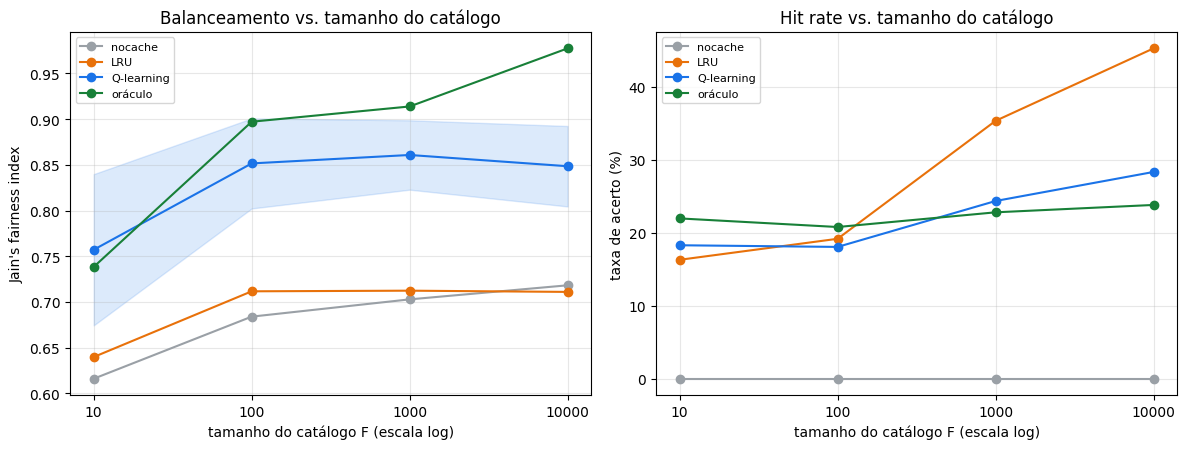

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
x = np.arange(len(Fs))
colors = {'nocache': '#9aa0a6', 'lru': '#e8710a', 'qlearn': '#1a73e8', 'oracle': '#188038'}
labels = {'nocache': 'nocache', 'lru': 'LRU', 'qlearn': 'Q-learning', 'oracle': 'oráculo'}

for m in ['nocache', 'lru', 'qlearn', 'oracle']:
    js  = np.array([scaling[F][m][0] for F in Fs])
    jstd = np.array([scaling[F][m][2] for F in Fs])
    ax[0].plot(x, js, 'o-', color=colors[m], label=labels[m])
    if m == 'qlearn':
        ax[0].fill_between(x, js - jstd, js + jstd, color=colors[m], alpha=.15)

ax[0].set_xticks(x); ax[0].set_xticklabels([str(F) for F in Fs])
ax[0].set_xlabel('tamanho do catálogo F (escala log)'); ax[0].set_ylabel("Jain's fairness index")
ax[0].set_title('Balanceamento vs. tamanho do catálogo'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

for m in ['nocache', 'lru', 'qlearn', 'oracle']:
    hs = np.array([scaling[F][m][1]*100 for F in Fs])
    ax[1].plot(x, hs, 'o-', color=colors[m], label=labels[m])

ax[1].set_xticks(x); ax[1].set_xticklabels([str(F) for F in Fs])
ax[1].set_xlabel('tamanho do catálogo F (escala log)'); ax[1].set_ylabel('taxa de acerto (%)')
ax[1].set_title('Hit rate vs. tamanho do catálogo'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()


In [13]:
# =====================================================================
# TESTE DE ESCALABILIDADE (10 Milhões de requisições, 100 Mil arquivos)
# =====================================================================

# 1. Definindo as novas escalas (mantendo a proporção de Cache em 5%)
F_novo = 100_000       # 100 mil arquivos no total
C_novo = 5_000         # Capacidade do cache: 5% de 100k
T_novo = 10_000_000    # 10 milhões de requisições

print(f"Gerando novo tráfego massivo... F={F_novo}, C={C_novo}, T={T_novo}")

# 2. Sobrescrevendo as variáveis de ambiente que a função run() usa
F, C, T = F_novo, C_novo, T_novo

# Recalculando o fluxo de acessos para 10 milhões e 100 mil arquivos
np.random.seed(0); random.seed(0)
p   = zipf(alpha, F)
req = np.random.choice(F, T, p=p)
catalog = np.array([1 if f % 3 == 0 else 0 for f in range(F)])
w = np.where(catalog == 0, 1.0, W2)

print("Iniciando a simulação...\n")

# 3. Rodamos a simulação e salvamos em um NOVO dicionário 'res_gigante'
res_gigante = {m: run(m) for m in ['nocache', 'lru', 'oracle', 'qlearn']}

# 4. Imprimindo os resultados escalados
print(f"\n{'política':<12}{'Jain':>8}{'hit rate':>10}   carga (A1, A2)")
print("-" * 46)
for m, label in [('nocache','nocache'), ('lru','LRU (clássico)'),
                 ('qlearn','Q-learning'), ('oracle','oráculo load-aware')]:
    r = res_gigante[m]
    print(f"{label:<18}{r['jain']:>6.3f}{r['hit']*100:>9.1f}%   [{r['A'][0]:.3f}, {r['A'][1]:.3f}]")

Gerando novo tráfego massivo... F=100000, C=5000, T=10000000
Iniciando a simulação...


política        Jain  hit rate   carga (A1, A2)
----------------------------------------------
nocache            0.769      0.0%   [0.700, 2.398]
LRU (clássico)     0.783     51.5%   [0.382, 1.229]
Q-learning         0.830     30.6%   [0.557, 1.480]
oráculo load-aware 0.944     24.2%   [0.700, 1.150]
